# Desikan-Killiany atlas schematic

> **Kernel:** `spin` env. DK atlas on the fsaverage **164k** surface, every cortical region a distinct
colour with 3-D sulcal shading (`bg_on_data=True`), for a figure schematic. Colours are assigned by an
**adjacency-aware** greedy pass (regions that border each other get perceptually distant colours, so no
two similar hues — e.g. two greens — sit side by side). Saves a PNG to `../outputs/figures/main/`.

Knobs in the setup cell: `HEMI`, `VIEWS`, `SEED` (reshuffle the palette / assignment).

## 0) Setup + adjacency-aware colouring

In [1]:
import os
import numpy as np, nibabel as nib
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from nilearn import datasets, plotting
from nilearn.surface import load_surf_mesh

PROJ=os.path.expanduser("~/Documents/Postdoc/projects/ASD-rarevar-annot")
DATA=f"{PROJ}/data/AHBA"; OUT=f"{PROJ}/outputs/figures/Fig1"; os.makedirs(OUT, exist_ok=True)
HEMI="right"; VIEWS=("lateral","medial"); SEED=0

fs=datasets.fetch_surf_fsaverage("fsaverage")               # 164k density
infl=fs[f"infl_{HEMI}"]; sulc=fs[f"sulc_{HEMI}"]
labels,ctab,names=nib.freesurfer.read_annot(f"{DATA}/{'lh' if HEMI=='left' else 'rh'}.aparc.annot")
names=[n.decode() if isinstance(n,bytes) else n for n in names]; n_reg=len(names)
labels=np.where(labels<0,0,labels)                          # medial-wall verts (-1) -> 'unknown'
grey={i for i,nm in enumerate(names) if nm.lower() in ("unknown","corpuscallosum","","medialwall")}

# --- which regions border each other (share a mesh edge) ---
fl=labels[load_surf_mesh(infl).faces]
pairs=np.vstack([fl[:,[0,1]],fl[:,[1,2]],fl[:,[0,2]]]); pairs=pairs[pairs[:,0]!=pairs[:,1]]
adj={i:set() for i in range(n_reg)}
for a,b in np.unique(pairs,axis=0): adj[a].add(b); adj[b].add(a)

# --- palette (no greys) + hue-weighted perceptual distance between colours ---
pal=np.vstack([plt.cm.tab20.colors, plt.cm.tab20b.colors, plt.cm.tab20c.colors])
pal=pal[(pal.max(1)-pal.min(1))>0.18]
np.random.default_rng(SEED).shuffle(pal)
hsv=mcolors.rgb_to_hsv(pal)
dh=np.abs(hsv[:,0][:,None]-hsv[:,0][None,:]); dh=np.minimum(dh,1-dh)     # circular hue
D=np.sqrt((2*dh)**2 + (hsv[:,1][:,None]-hsv[:,1][None,:])**2 + (hsv[:,2][:,None]-hsv[:,2][None,:])**2)

# --- greedy DSATUR: high-degree regions first; each takes the unused colour that
#     maximises the minimum distance to its already-coloured neighbours ---
order=sorted([i for i in range(n_reg) if i not in grey], key=lambda i:-len(adj[i]))
assigned={}; used=set()
for r in order:
    nbr=[assigned[k] for k in adj[r] if k in assigned]
    cands=[j for j in range(len(pal)) if j not in used]
    best=max(cands, key=lambda j: min(D[j,c] for c in nbr)) if nbr else cands[0]
    assigned[r]=best; used.add(best)
colors=np.tile([0.82,0.82,0.82,1.0],(n_reg,1))              # medial wall / non-cortex -> grey
for r,j in assigned.items(): colors[r]=[*pal[j],1.0]
cmap=ListedColormap(colors)
print(f"{HEMI}: coloured {len(assigned)} regions from a {len(pal)}-colour palette")

[fetch_surf_fsaverage] Dataset directory found: /Users/rachelsmith/nilearn_data/fsaverage
right: coloured 34 regions from a 49-colour palette


## 1) Render + save

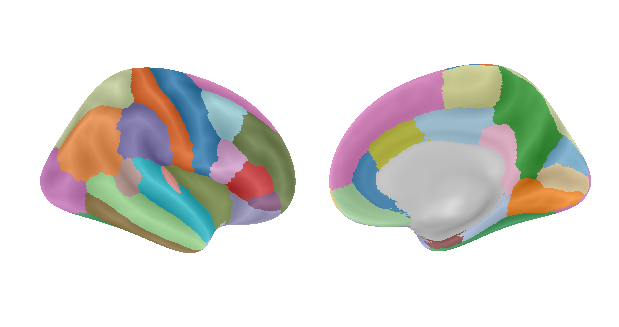

saved ../outputs/figures/schematic/dk_atlas_schematic_right_164k.png


In [2]:
fig,axes=plt.subplots(1,len(VIEWS),figsize=(3.0*len(VIEWS),3.2),subplot_kw={"projection":"3d"})
for ax,view in zip(np.atleast_1d(axes),VIEWS):
    plotting.plot_surf_roi(infl,roi_map=labels,hemi=HEMI,view=view,cmap=cmap,vmin=0,vmax=n_reg-1,
                           bg_map=sulc,bg_on_data=True,colorbar=False,axes=ax,figure=fig)
fig.subplots_adjust(left=0,right=1,top=1,bottom=0,wspace=-0.05)
out=f"{OUT}/dk_atlas_schematic_{HEMI}_164k.png"
fig.savefig(out,dpi=300,bbox_inches="tight",pad_inches=0); plt.show()
print("saved",out)